# Core \#2 — Global Macro Risk-On / Risk-Off HMM

**Project:** STML Metamodel Feature Engineering
**Author:** Harry Browne
**Model:** Gaussian HMM, M selected ∈ {2, 3}, d = 4 macro features
**Purpose:** Generate a single global regime indicator (risk-on / risk-off)
broadcast to all 11 instruments in the 645-day metamodel window.

---

This notebook documents the **global macro regime HMM** (Core \#2).
A single HMM is fitted to a 4-dimensional macro observation vector, capturing
broad cross-asset risk appetite.  The state ordering makes state 0 = risk-on
(low spreads, low VIX, steeper curve) and the highest state = risk-off / stress.

### Outline

1. [Observation features — what and why](#obs)
2. [Data loading and feature inspection](#data)
3. [Pre-sample split and standardisation](#split)
4. [M selection: BIC + forward-chain TS-CV](#mselect)
5. [Learned parameters: transition matrix and state means](#params)
6. [Regime-over-time plot](#regime)
7. [Dwell-time sanity check](#dwell)
8. [Filter-forward into the metamodel window](#filter)
9. [Feature extraction and preview](#features)


In [1]:
import warnings
warnings.filterwarnings("ignore")

import sys, os
sys.path.insert(0, os.path.join(os.path.dirname(os.getcwd()), "..", "src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from pathlib import Path
from hmmlearn.hmm import GaussianHMM
from scipy.special import logsumexp
from sklearn.preprocessing import StandardScaler

np.random.seed(42)
sns.set_theme(style="whitegrid", palette="muted")

REPO       = Path("../..").resolve()
MACRO_PATH = REPO / "data" / "meta" / "macro_features.csv"
PS_PATH    = REPO / "data" / "primary_signals.csv"
OUT_PATH   = REPO / "src" / "stml" / "new_work" / "features_hmm_macro.csv"

FEATURES = [
    "f11_hy_oas_z",
    "f11_vix_level_z",
    "f11_us_2s10s_slope",
    "f11_dxy_5d_change",
]
INSTRUMENTS = ["es1s","nq1s","fesx1s","cl1s","ho1s","rb1s","ng1s","gc1s","si1s","hg1s","pl1s"]
N_RESTARTS = 20
N_ITER     = 300
N_CV       = 5

macro = pd.read_csv(MACRO_PATH, parse_dates=["Date"])
ps    = pd.read_csv(PS_PATH,    parse_dates=["date"])

CUTOFF     = ps["date"].min()
META_DATES = set(ps["date"])
print(f"Macro rows: {len(macro):,}  |  Pre-sample cutoff: {CUTOFF.date()}")


Macro rows: 8,478  |  Pre-sample cutoff: 2020-01-03


---
<a id="obs"></a>
## 1  Observation Features — What and Why

Four daily macro time-series capture orthogonal dimensions of risk appetite:

| Feature | Interpretation | Risk-off direction |
|---------|---------------|-------------------|
| `f11_hy_oas_z` | High-yield option-adjusted spread z-score | ↑ wide spreads = stress |
| `f11_vix_level_z` | VIX level z-score | ↑ fear / equity vol |
| `f11_us_2s10s_slope` | US 2s10s yield-curve slope | ↓ flat/inverted = slowdown |
| `f11_dxy_5d_change` | 5-day USD index change | ↑ dollar strength = flight-to-safety* |

\* The DXY effect depends on regime: in pure credit stress (2008) the dollar
strengthens as a safe haven; but in inflationary episodes (2022) a strong dollar
coincides with risk-on commodity demand.  Including it alongside VIX and HY OAS
lets the model learn this context-dependence in the joint distribution.

The features are **already engineered** in `macro_features.csv` (z-scores relative
to rolling history, 5-day changes).  We standardise them on the pre-sample before
feeding to the HMM to ensure comparability of emission means across features.


---
<a id="data"></a>
## 2  Data Loading and Feature Inspection


Clean rows (all 4 features non-null): 7,355
Earliest date with all 4 features: 1994-04-22


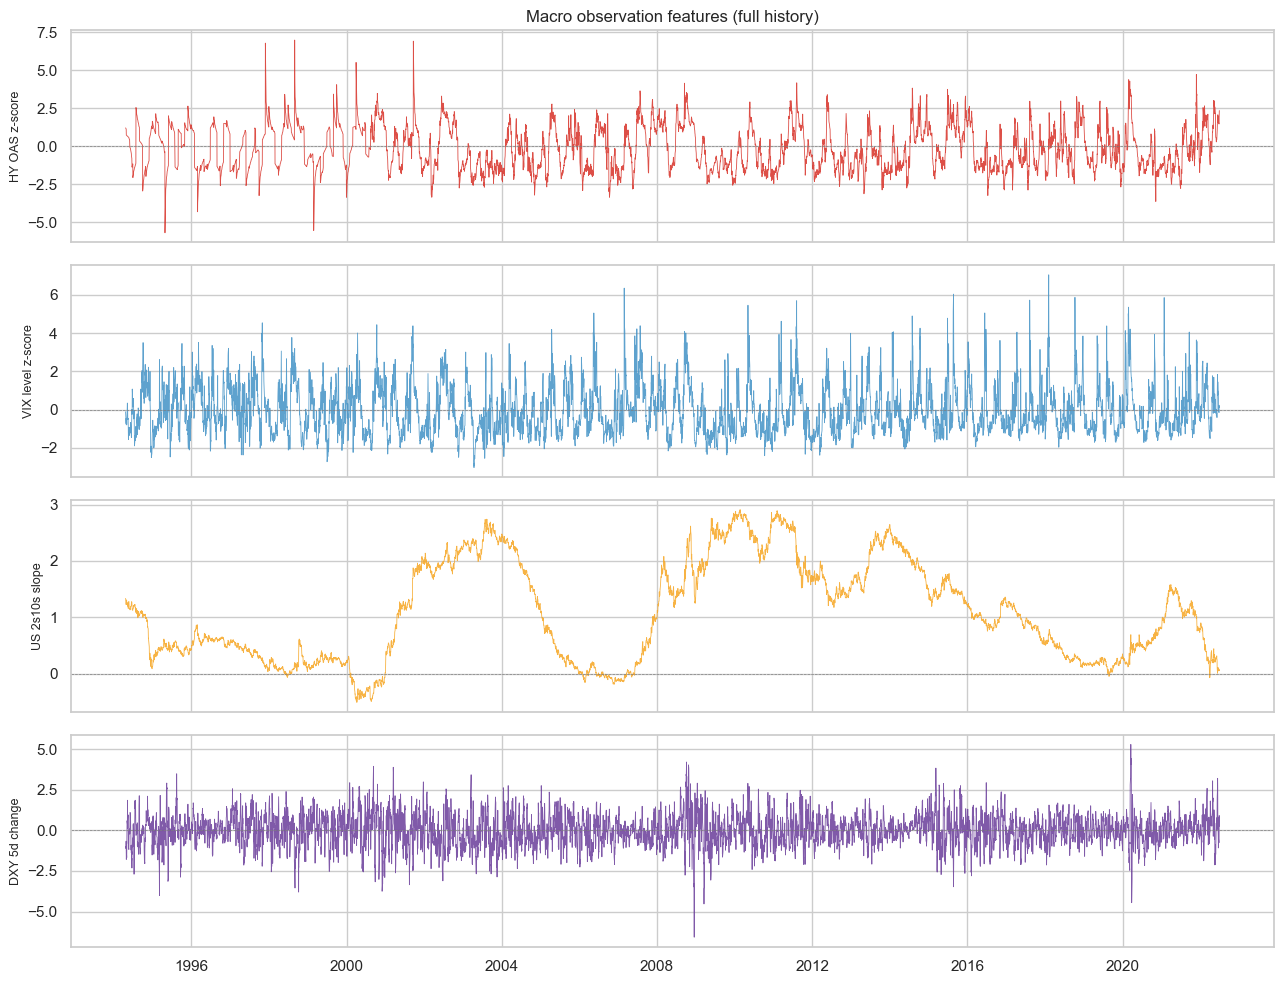

In [2]:
macro_clean = macro[["Date"] + FEATURES].dropna().copy()
print(f"Clean rows (all 4 features non-null): {len(macro_clean):,}")
print(f"Earliest date with all 4 features: {macro_clean['Date'].min().date()}")

# Feature time series
fig, axes = plt.subplots(4, 1, figsize=(13, 10), sharex=True)
colors = ["#d73027","#4292c6","#f6a623","#6a3d9a"]
labels = [
    "HY OAS z-score",
    "VIX level z-score",
    "US 2s10s slope",
    "DXY 5d change",
]
for ax, col, color, lbl in zip(axes, FEATURES, colors, labels):
    ax.plot(macro_clean["Date"], macro_clean[col], lw=0.6, color=color, alpha=0.85)
    ax.axhline(0, color="grey", lw=0.5, ls="--")
    ax.set_ylabel(lbl, fontsize=9)
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
axes[0].set_title("Macro observation features (full history)", fontsize=12)
plt.tight_layout(); plt.savefig("_tmp_nb2_feats.png", dpi=120, bbox_inches="tight"); plt.show()


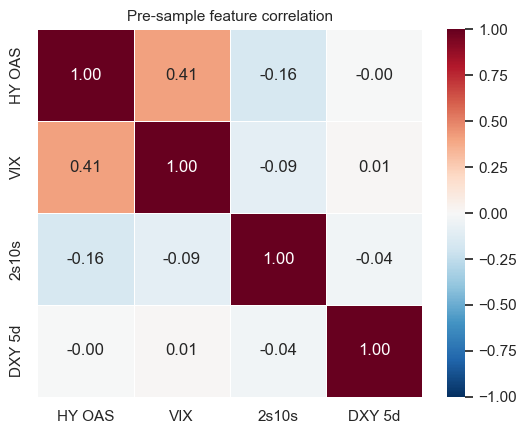

HY OAS and VIX are positively correlated — both capture stress.
2s10s is negatively correlated with them — flat/inverted curve accompanies stress.
DXY 5d is closer to neutral — context-dependent.


In [3]:
# Pre-sample correlation matrix
pre_clean = macro_clean[macro_clean["Date"] < CUTOFF][FEATURES]
corr = pre_clean.corr()

fig, ax = plt.subplots(figsize=(5.5, 4.5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            vmin=-1, vmax=1, linewidths=0.5, ax=ax,
            xticklabels=["HY OAS","VIX","2s10s","DXY 5d"], yticklabels=["HY OAS","VIX","2s10s","DXY 5d"])
ax.set_title("Pre-sample feature correlation", fontsize=11)
plt.tight_layout(); plt.savefig("_tmp_nb2_corr.png", dpi=120, bbox_inches="tight"); plt.show()
print("HY OAS and VIX are positively correlated — both capture stress.\n"
      "2s10s is negatively correlated with them — flat/inverted curve accompanies stress.\n"
      "DXY 5d is closer to neutral — context-dependent.")


---
<a id="split"></a>
## 3  Pre-Sample Split and Standardisation

The pre-sample for the macro HMM is **1994-04-22 → 2019-12-31** (the earliest
date where all four features are jointly non-null, through the cutoff).
This gives approximately 6,700 trading days — ample data for the HMM.

Standardisation: `StandardScaler` is fit on the pre-sample features only.
The same scaler (frozen) is then applied to the full sequence for filtering.


In [4]:
presample = macro_clean[macro_clean["Date"] < CUTOFF]
full      = macro_clean.copy()

print(f"Pre-sample: {presample['Date'].min().date()} → {presample['Date'].max().date()}  ({len(presample):,} rows)")
print(f"Full (pre + meta): {full['Date'].min().date()} → {full['Date'].max().date()}  ({len(full):,} rows)")

scaler = StandardScaler()
X_pre  = scaler.fit_transform(presample[FEATURES].values)
X_full = scaler.transform(full[FEATURES].values)

print(f"\nPre-sample standardised:  mean={X_pre.mean():.4f}  std={X_pre.std():.4f}")
print(f"Pre-sample feature means before scaling:\n{presample[FEATURES].mean().round(3).to_string()}")


Pre-sample: 1994-04-22 → 2020-01-02  (6,705 rows)
Full (pre + meta): 1994-04-22 → 2022-06-30  (7,355 rows)

Pre-sample standardised:  mean=0.0000  std=1.0000
Pre-sample feature means before scaling:
f11_hy_oas_z         -0.143
f11_vix_level_z      -0.045
f11_us_2s10s_slope    1.118
f11_dxy_5d_change     0.002


---
<a id="mselect"></a>
## 4  M Selection: BIC + Forward-Chain TS-CV

### Method

We compare **M = 2** (risk-on / risk-off) and **M = 3** (risk-on / neutral / risk-off)
using two information criteria evaluated on the pre-sample:

**BIC** (Bayesian Information Criterion):

$$\text{BIC} = -2\,\ell_{\text{total}} + k\,\ln n$$

where $k = (M-1) + M(M-1) + 2Md$ free parameters and $n$ is the pre-sample length.
Lower BIC = better.

**Forward-chain time-series CV**: the pre-sample is split into $N_{\text{CV}}+1$
non-overlapping folds.  Fold $i$ trains on the first $i$ folds and evaluates on
fold $i+1$, preserving temporal order.  Metric: mean per-observation held-out
log-likelihood (higher = better).  This is a prospective evaluation matching
how the model will be used in production.

**Decision rule**: pick M where BIC and CV agree; if they disagree, tie-break
toward **fewer states** (parsimony, longer dwell times, more interpretable regimes).


In [5]:
# --- Shared HMM helpers ---

def _gaussian_log_emit(X, means, covars):
    T, M = X.shape[0], len(means)
    log_emit = np.empty((T, M))
    for m in range(M):
        mu  = means[m]
        c   = covars[m]
        var = np.diag(c) if c.ndim == 2 else c
        log_emit[:, m] = -0.5 * (
            np.sum(((X - mu)**2)/var, axis=1) + np.sum(np.log(2*np.pi*var))
        )
    return log_emit

def filter_forward(model, X):
    """Scaled forward algorithm → filtering posteriors p(H_t|X_1:t)."""
    T, M = X.shape[0], model.n_components
    log_emit = _gaussian_log_emit(X, model.means_, model.covars_)
    log_pi = np.log(np.clip(model.startprob_, 1e-300, 1.0))
    log_Q  = np.log(np.clip(model.transmat_,  1e-300, 1.0))
    log_alpha = log_pi + log_emit[0]; log_alpha -= logsumexp(log_alpha)
    filtered = np.empty((T, M)); filtered[0] = np.exp(log_alpha)
    for t in range(1, T):
        log_alpha = logsumexp(log_alpha[:,None] + log_Q, axis=0) + log_emit[t]
        log_alpha -= logsumexp(log_alpha)
        filtered[t] = np.exp(log_alpha)
    return filtered

def fit_hmm_best(X, n, n_restarts=N_RESTARTS, n_iter=N_ITER, seed=42):
    best, best_ll = None, -np.inf
    for i in range(n_restarts):
        m = GaussianHMM(n_components=n, covariance_type="diag",
                        n_iter=n_iter, random_state=seed+i, tol=1e-5)
        try:
            m.fit(X); ll = m.score(X)
            if np.isfinite(ll) and ll > best_ll:
                best_ll, best = ll, m
        except Exception:
            pass
    return best, best_ll

def n_free_params(M, d):
    return (M-1) + M*(M-1) + 2*M*d

def compute_bic(model, X):
    T = len(X)
    k = n_free_params(model.n_components, X.shape[1])
    return -2.0 * model.score(X) + k * np.log(T)   # score() = total log-lik

def ts_cv_loglik(X, n, n_splits=N_CV, seed=42):
    """Mean per-obs held-out log-lik via forward-chaining CV."""
    T = len(X)
    lls = []
    for fold in range(1, n_splits+1):
        tr_end = int(T * fold / (n_splits+1))
        va_end = int(T * (fold+1) / (n_splits+1))
        Xtr, Xva = X[:tr_end], X[tr_end:va_end]
        if len(Xtr) < 200 or len(Xva) < 20:
            continue
        m, _ = fit_hmm_best(Xtr, n, seed=seed)
        if m is not None:
            lls.append(m.score(Xva) / len(Xva))
    return float(np.mean(lls)) if lls else -np.inf

def sort_states_by_risk(model, vix_idx, oas_idx):
    """Sort by ascending VIX+OAS mean: state 0 = risk-on."""
    risk  = model.means_[:, vix_idx] + model.means_[:, oas_idx]
    order = np.argsort(risk)
    model.startprob_ = model.startprob_[order]
    model.transmat_  = model.transmat_[np.ix_(order, order)]
    model.means_     = model.means_[order]
    model._covars_   = model._covars_[order]
    return model

VIX_IDX = FEATURES.index("f11_vix_level_z")
OAS_IDX = FEATURES.index("f11_hy_oas_z")

print("Helpers defined.")


Helpers defined.


In [6]:
# Fit M=2 and M=3, compute metrics
sel_rows = []
models   = {}
print("Fitting M=2 and M=3 on pre-sample (20 restarts each + TS-CV)...\n")
for M in [2, 3]:
    m, ll = fit_hmm_best(X_pre, M)
    bic   = compute_bic(m, X_pre)
    cv    = ts_cv_loglik(X_pre, M)
    models[M] = (m, ll)
    sel_rows.append({
        "M": M,
        "log-lik / obs": round(ll / len(X_pre), 4),
        "BIC": round(bic, 1),
        "CV log-lik / obs": round(cv, 4),
    })
    print(f"  M={M}:  log-lik/obs={ll/len(X_pre):.4f}  BIC={bic:.1f}  CV-ll/obs={cv:.4f}")

sel_df = pd.DataFrame(sel_rows).set_index("M")
print()
print("Selection table:")
print(sel_df.to_string())


Fitting M=2 and M=3 on pre-sample (20 restarts each + TS-CV)...



  M=2:  log-lik/obs=-4.9623  BIC=66711.8  CV-ll/obs=-5.8019


Model is not converging.  Current: -3751.1006311669735 is not greater than -3751.1006258130637. Delta is -5.353909728000872e-06


Model is not converging.  Current: -3773.296280638753 is not greater than -3773.2962782360837. Delta is -2.4026694518397562e-06


Model is not converging.  Current: -3686.0598900846876 is not greater than -3686.059877676406. Delta is -1.2408281691023149e-05


Model is not converging.  Current: -9510.135104425108 is not greater than -9510.13510228623. Delta is -2.138876880053431e-06


Model is not converging.  Current: -9510.135105017283 is not greater than -9510.135102403121. Delta is -2.614162440295331e-06


  M=3:  log-lik/obs=-4.4010  BIC=59299.8  CV-ll/obs=-6.7652

Selection table:
   log-lik / obs      BIC  CV log-lik / obs
M                                          
2        -4.9623  66711.8           -5.8019
3        -4.4010  59299.8           -6.7652


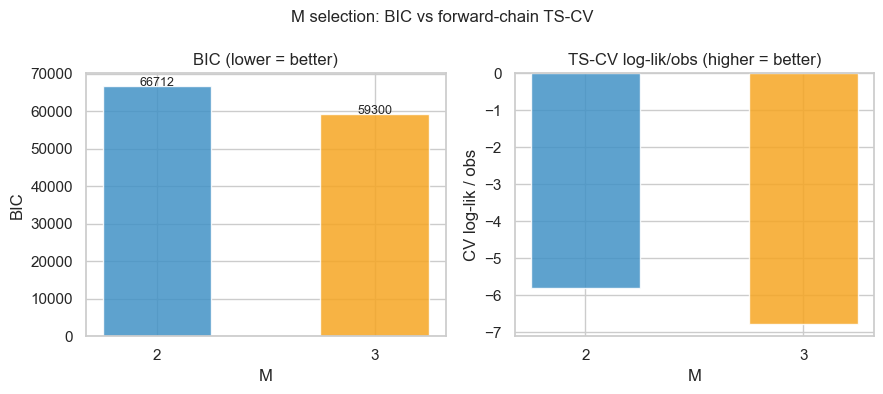

In [7]:
# Visualise BIC and CV comparison
fig, axes = plt.subplots(1, 2, figsize=(9, 4))

axes[0].bar([2, 3], sel_df["BIC"], color=["#4292c6","#f6a623"], width=0.5, alpha=0.85)
axes[0].set_xlabel("M"); axes[0].set_ylabel("BIC")
axes[0].set_title("BIC (lower = better)")
axes[0].set_xticks([2, 3])
for i, (m, row) in enumerate(sel_df.iterrows()):
    axes[0].text(m, row["BIC"]*1.001, f"{row['BIC']:.0f}", ha="center", fontsize=9)

axes[1].bar([2, 3], sel_df["CV log-lik / obs"], color=["#4292c6","#f6a623"], width=0.5, alpha=0.85)
axes[1].set_xlabel("M"); axes[1].set_ylabel("CV log-lik / obs")
axes[1].set_title("TS-CV log-lik/obs (higher = better)")
axes[1].set_xticks([2, 3])

plt.suptitle("M selection: BIC vs forward-chain TS-CV", fontsize=12)
plt.tight_layout(); plt.savefig("_tmp_nb2_mselect.png", dpi=120, bbox_inches="tight"); plt.show()


In [8]:
bic_better = "M=2" if sel_df.loc[2,"BIC"] < sel_df.loc[3,"BIC"] else "M=3"
cv_better  = "M=2" if sel_df.loc[2,"CV log-lik / obs"] > sel_df.loc[3,"CV log-lik / obs"] else "M=3"

print(f"BIC favours: {bic_better}")
print(f"TS-CV favours: {cv_better}")

if bic_better == cv_better:
    CHOSEN_M = int(bic_better[-1])
    print(f"\nBIC and CV agree → Chosen M={CHOSEN_M}")
else:
    CHOSEN_M = 2
    print(f"\nBIC and CV disagree → Tie-break to fewer states → Chosen M={CHOSEN_M}")
    print("Reasoning: fewer states means longer expected dwell times and more")
    print("interpretable, persistent regimes — appropriate for a global risk indicator.")


BIC favours: M=3
TS-CV favours: M=2

BIC and CV disagree → Tie-break to fewer states → Chosen M=2
Reasoning: fewer states means longer expected dwell times and more
interpretable, persistent regimes — appropriate for a global risk indicator.


---
<a id="params"></a>
## 5  Learned Parameters

### 5.1  Final model fit with M = 2


Final model: M=2  |  pre-sample log-lik/obs = -4.9623

Transition matrix Q:
              Risk-On (0)  Risk-Off (1)
Risk-On (0)        0.9830        0.0170
Risk-Off (1)       0.0212        0.9788


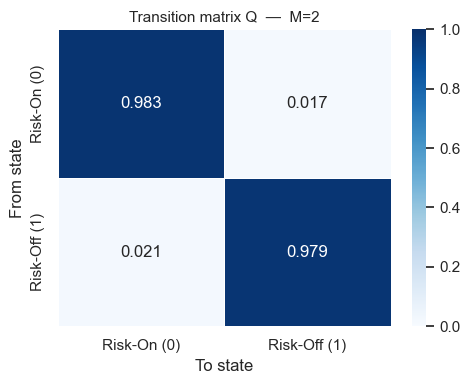

In [9]:
final_model, final_ll = fit_hmm_best(X_pre, CHOSEN_M)
final_model = sort_states_by_risk(final_model, VIX_IDX, OAS_IDX)

state_labels = ["Risk-On (0)", "Risk-Off (1)"] if CHOSEN_M == 2 else ["Risk-On (0)", "Neutral (1)", "Risk-Off (2)"]

print(f"Final model: M={CHOSEN_M}  |  pre-sample log-lik/obs = {final_ll/len(X_pre):.4f}")

# Transition matrix
Q = final_model.transmat_
print(f"\nTransition matrix Q:")
Q_df = pd.DataFrame(Q, index=state_labels[:CHOSEN_M], columns=state_labels[:CHOSEN_M])
print(Q_df.round(4).to_string())

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(Q_df, annot=True, fmt=".3f", cmap="Blues", vmin=0, vmax=1,
            linewidths=0.5, ax=ax)
ax.set_title(f"Transition matrix Q  —  M={CHOSEN_M}", fontsize=11)
ax.set_ylabel("From state"); ax.set_xlabel("To state")
plt.tight_layout(); plt.savefig("_tmp_nb2_transmat.png", dpi=120, bbox_inches="tight"); plt.show()


Per-state emission means (standardised):
              HY OAS z  VIX z  2s10s slope  DXY 5d
Risk-On (0)     -0.763 -0.361        0.194   0.015
Risk-Off (1)     0.937  0.443       -0.238  -0.018

Interpretation:
  State 0 (Risk-On):  tight HY spreads, low VIX, steeper yield curve → growth regime
  State 1 (Risk-Off): wide HY spreads, elevated VIX, flatter/inverted curve → stress


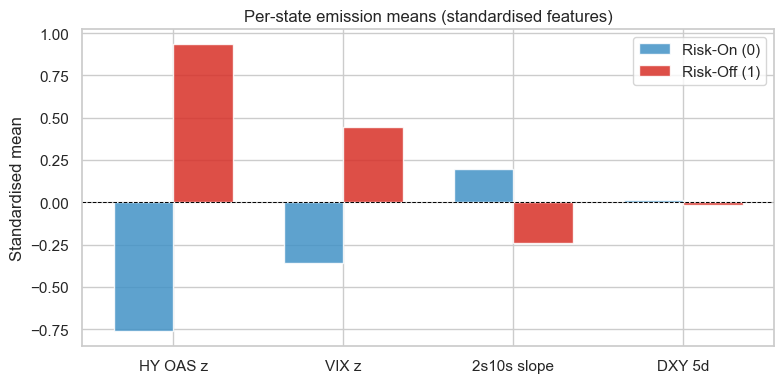

In [10]:
# Per-state means (standardised)
means_df = pd.DataFrame(final_model.means_, index=state_labels[:CHOSEN_M], columns=FEATURES)
means_df.columns = ["HY OAS z","VIX z","2s10s slope","DXY 5d"]

print("Per-state emission means (standardised):")
print(means_df.round(3).to_string())
print()
print("Interpretation:")
print("  State 0 (Risk-On):  tight HY spreads, low VIX, steeper yield curve → growth regime")
print("  State 1 (Risk-Off): wide HY spreads, elevated VIX, flatter/inverted curve → stress")

fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(4)
w = 0.35 if CHOSEN_M == 2 else 0.25
colors = ["#4292c6","#d73027","#f6a623"]
for k, (lbl, row) in enumerate(means_df.iterrows()):
    ax.bar(x + k*w, row.values, width=w, label=lbl, color=colors[k], alpha=0.85)
ax.set_xticks(x + w*(CHOSEN_M-1)/2)
ax.set_xticklabels(["HY OAS z","VIX z","2s10s slope","DXY 5d"])
ax.axhline(0, color="black", lw=0.7, ls="--")
ax.set_ylabel("Standardised mean"); ax.set_title("Per-state emission means (standardised features)")
ax.legend(); plt.tight_layout(); plt.savefig("_tmp_nb2_means.png", dpi=120, bbox_inches="tight"); plt.show()


---
<a id="regime"></a>
## 6  Regime-Over-Time Plot

We run the forward filter on the complete sequence to visualise the global
macro regime.  Prominent risk-off episodes (dot-com bust, GFC 2008–09,
COVID March 2020, 2022 tightening cycle) should clearly show as state-1
dominance.


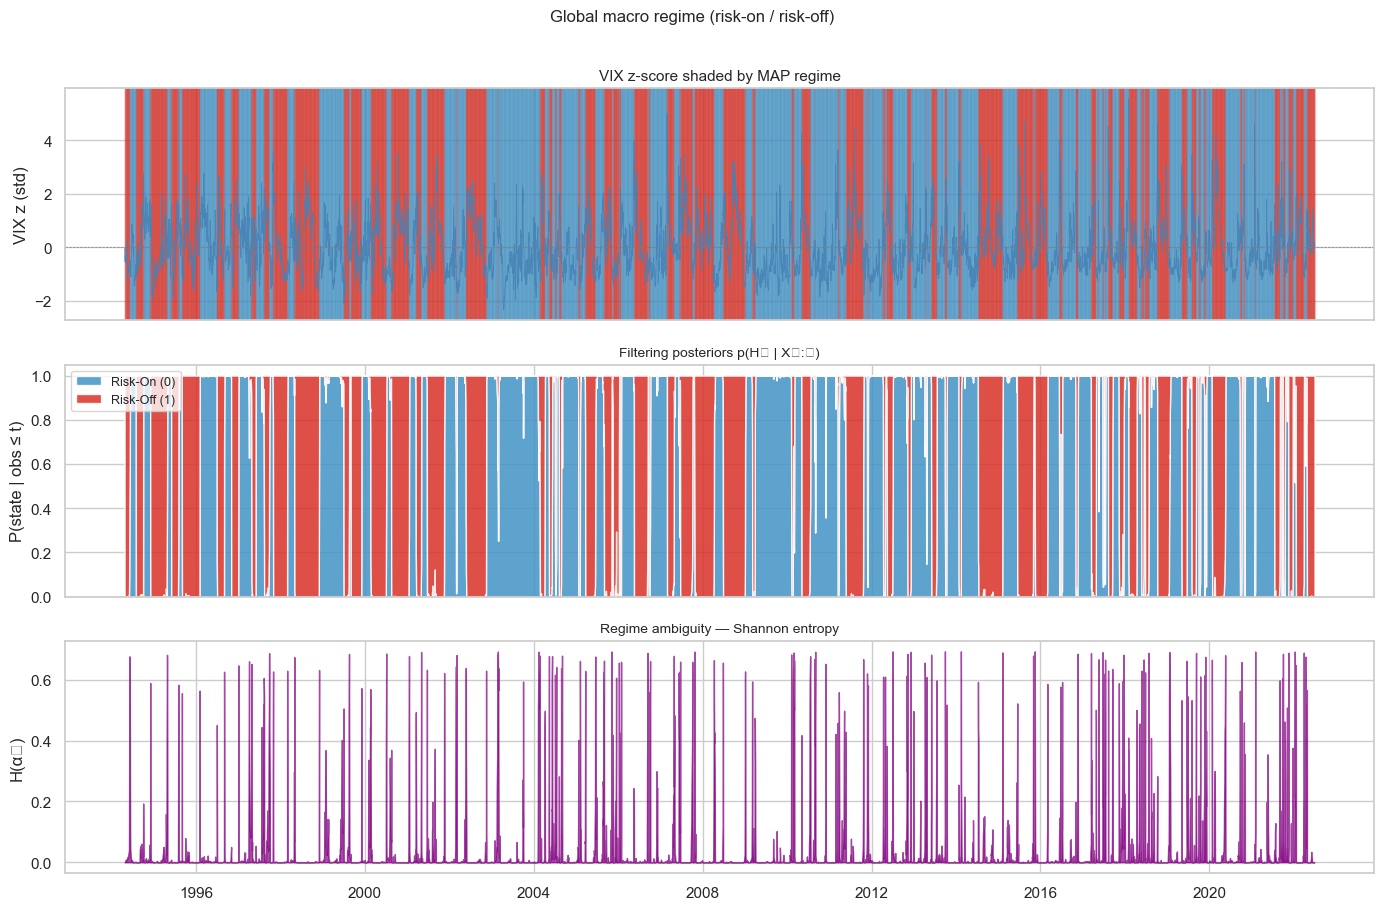

In [11]:
filtered_full = filter_forward(final_model, X_full)
full_dates    = full["Date"].values

state_colors = ["#4292c6","#d73027","#f6a623"]

fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)

# Top: VIX z-score (raw feature) shaded by MAP state
MAP_state = np.argmax(filtered_full, axis=1)
axes[0].plot(full_dates, X_full[:, VIX_IDX], lw=0.6, color="steelblue", alpha=0.85)
for t in range(len(full_dates)-1):
    axes[0].axvspan(full_dates[t], full_dates[t+1], color=state_colors[MAP_state[t]], alpha=0.15)
axes[0].set_ylabel("VIX z (std)"); axes[0].set_title("VIX z-score shaded by MAP regime", fontsize=11)
axes[0].axhline(0, color="grey", lw=0.5, ls="--")

# Middle: filtering posteriors stacked
axes[1].stackplot(
    full_dates,
    *[filtered_full[:,m] for m in range(CHOSEN_M)],
    labels=state_labels[:CHOSEN_M], colors=state_colors[:CHOSEN_M], alpha=0.85
)
axes[1].set_ylabel("P(state | obs ≤ t)"); axes[1].legend(loc="upper left", fontsize=9)
axes[1].set_title("Filtering posteriors p(Hₜ | X₁:ₜ)", fontsize=10)

# Bottom: entropy
entropy = -np.sum(filtered_full * np.log(np.clip(filtered_full,1e-300,1)), axis=1)
axes[2].fill_between(full_dates, entropy, alpha=0.7, color="purple")
axes[2].set_ylabel("H(αₜ)"); axes[2].set_title("Regime ambiguity — Shannon entropy", fontsize=10)

axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
plt.suptitle("Global macro regime (risk-on / risk-off)", fontsize=12, y=1.01)
plt.tight_layout(); plt.savefig("_tmp_nb2_regime.png", dpi=120, bbox_inches="tight"); plt.show()


---
<a id="dwell"></a>
## 7  Dwell-Time Sanity Check

Expected dwell time $= 1 / (1 - Q_{mm})$.  For a global macro regime to be
useful, it must persist for at least a few weeks — otherwise it is not capturing
a regime but noise.


In [12]:
print("Expected dwell times (trading days):")
for i, lbl in enumerate(state_labels[:CHOSEN_M]):
    dwell = 1.0 / (1.0 - final_model.transmat_[i,i])
    print(f"  {lbl}: {dwell:.1f} days  ≈  {dwell/21:.1f} months")

print()
print("Transition probabilities:")
for i, lbl_i in enumerate(state_labels[:CHOSEN_M]):
    for j, lbl_j in enumerate(state_labels[:CHOSEN_M]):
        if i != j:
            p = final_model.transmat_[i,j]
            print(f"  P({lbl_j} | {lbl_i}) = {p:.4f}  (≈ once every {1/p:.0f} days)")


Expected dwell times (trading days):
  Risk-On (0): 58.8 days  ≈  2.8 months
  Risk-Off (1): 47.2 days  ≈  2.2 months

Transition probabilities:
  P(Risk-Off (1) | Risk-On (0)) = 0.0170  (≈ once every 59 days)
  P(Risk-On (0) | Risk-Off (1)) = 0.0212  (≈ once every 47 days)


---
<a id="filter"></a>
## 8  Filter-Forward into the Metamodel Window

Same design as Core \#1: run the forward pass from the beginning of time,
freeze parameters, extract only the metamodel-window rows.

The macro features are applied globally — one row per date, then broadcast
to all 11 instruments.


---
<a id="features"></a>
## 9  Feature Extraction and Preview

### Feature definitions

| Feature | Formula | Interpretation |
|---------|---------|---------------|
| `hmm_macro_p0` | $\alpha_t[0]$ | P(risk-on at t | obs ≤ t) |
| `hmm_macro_next_riskoff` | $\alpha_t \cdot Q_{:,M-1}$ | One-step P(risk-off tomorrow) |
| `hmm_macro_entropy` | $-\sum_m \alpha_t[m]\ln\alpha_t[m]$ | Regime ambiguity |

`p_{M-1}` (risk-off) is dropped (redundant given sum-to-1).
For M=2 there is exactly one posterior column; for M=3 there would be two (p0, p1).


In [13]:
records = []
riskoff_idx = CHOSEN_M - 1
Q = final_model.transmat_

for idx, d in enumerate(full["Date"].values):
    d_ts = pd.Timestamp(d)
    if d_ts not in META_DATES:
        continue
    alpha = filtered_full[idx]
    row   = {"date": d_ts}
    for s in range(CHOSEN_M - 1):
        row[f"hmm_macro_p{s}"] = float(alpha[s])
    row["hmm_macro_next_riskoff"] = float(alpha @ Q[:, riskoff_idx])
    row["hmm_macro_entropy"]      = float(-np.sum(alpha * np.log(np.clip(alpha,1e-300,1.0))))
    records.append(row)

date_df = pd.DataFrame(records)

# Broadcast to all instruments
frames = []
for inst in INSTRUMENTS:
    df_inst = date_df.copy(); df_inst["instrument"] = inst; frames.append(df_inst)

feat_cols   = [c for c in date_df.columns if c != "date"]
features_macro = (
    pd.concat(frames).sort_values(["date","instrument"]).reset_index(drop=True)
)
features_macro = features_macro[["date","instrument"] + feat_cols]

print(f"Feature matrix: {features_macro.shape}  ({features_macro['date'].nunique()} dates × {features_macro['instrument'].nunique()} instruments)")
print()
print("Sample (first date):")
print(features_macro[features_macro["date"] == features_macro["date"].min()].head(5).to_string(index=False))


Feature matrix: (7095, 5)  (645 dates × 11 instruments)

Sample (first date):
      date instrument  hmm_macro_p0  hmm_macro_next_riskoff  hmm_macro_entropy
2020-01-03       cl1s      0.999298                 0.01767           0.005796
2020-01-03       es1s      0.999298                 0.01767           0.005796
2020-01-03     fesx1s      0.999298                 0.01767           0.005796
2020-01-03       gc1s      0.999298                 0.01767           0.005796
2020-01-03       hg1s      0.999298                 0.01767           0.005796


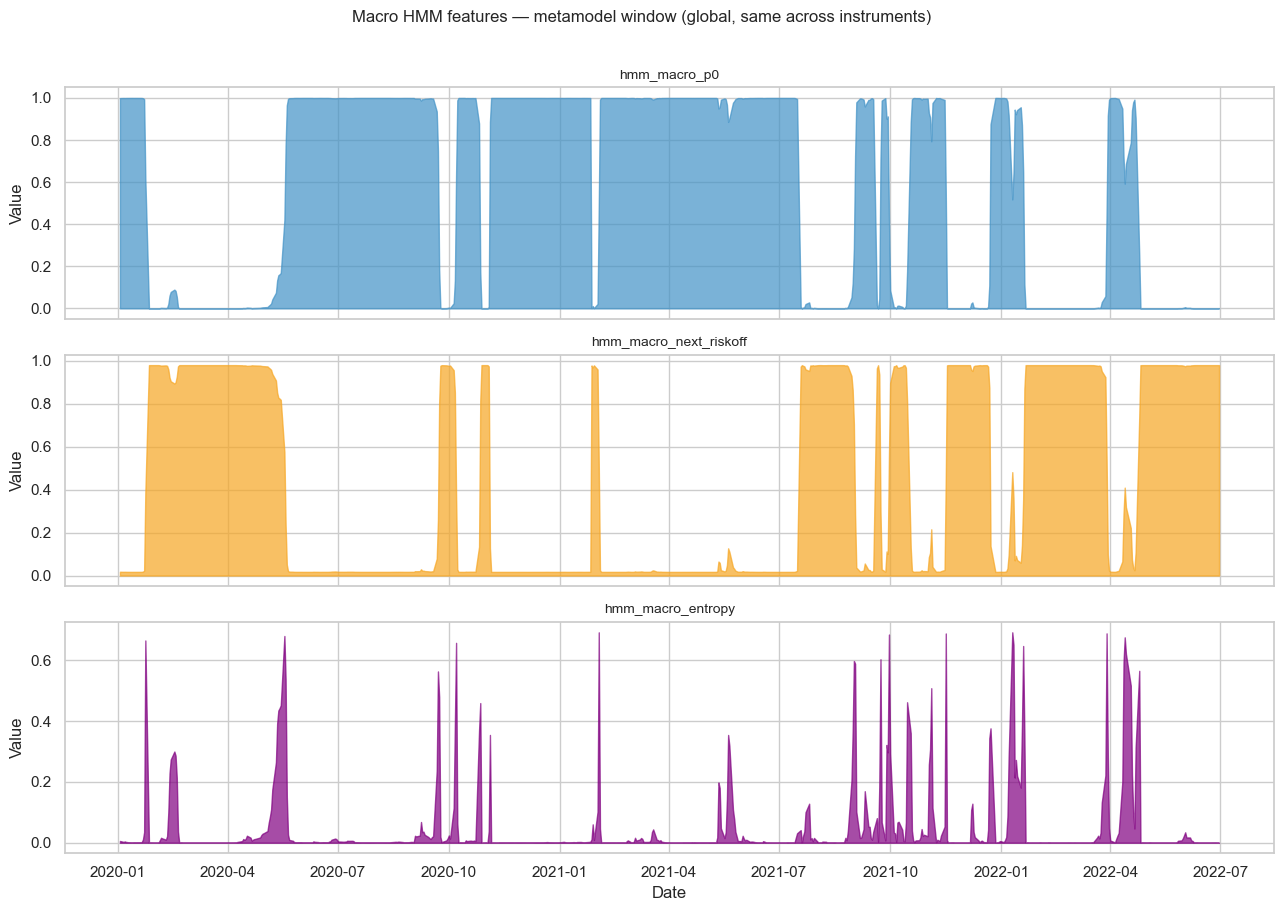

In [14]:
# Time-series plot (global — same for all instruments)
meta_global = features_macro[features_macro["instrument"]=="es1s"].set_index("date")

feat_plot = [c for c in feat_cols if c in meta_global.columns]
fig, axes = plt.subplots(len(feat_plot), 1, figsize=(13, 3*len(feat_plot)), sharex=True)
if len(feat_plot) == 1:
    axes = [axes]
colors = ["#4292c6","#f6a623","purple"]
for ax, col, color in zip(axes, feat_plot, colors):
    ax.fill_between(meta_global.index, meta_global[col], alpha=0.7, color=color)
    ax.set_title(col, fontsize=10); ax.set_ylabel("Value")
axes[-1].set_xlabel("Date")
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
plt.suptitle("Macro HMM features — metamodel window (global, same across instruments)", fontsize=12, y=1.01)
plt.tight_layout(); plt.savefig("_tmp_nb2_features.png", dpi=120, bbox_inches="tight"); plt.show()


In [15]:
print("Feature summary statistics:")
print(features_macro[feat_cols].describe().round(4).to_string())

features_macro.to_csv(OUT_PATH, index=False)
print(f"\nSaved {len(features_macro):,} rows → {OUT_PATH}")
print("\nDone.  Features ready to merge into metamodel by (date, instrument).")


Feature summary statistics:
       hmm_macro_p0  hmm_macro_next_riskoff  hmm_macro_entropy
count     7095.0000               7095.0000          7095.0000
mean         0.5734                  0.4273             0.0511
std          0.4796                  0.4613             0.1336
min          0.0000                  0.0170             0.0000
25%          0.0004                  0.0171             0.0002
50%          0.9885                  0.0281             0.0018
75%          0.9998                  0.9784             0.0170
max          1.0000                  0.9788             0.6925

Saved 7,095 rows → /Users/harrybrowne/Downloads/Imperial Work/SystematicTrading/stml/src/stml/new_work/features_hmm_macro.csv

Done.  Features ready to merge into metamodel by (date, instrument).
